# PINN exercises

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

import torch
import torch.nn as nn

## Sheet 1

### 1.10a

Compare forward and backward Euler on $\frac{dx}{dt}=-\alpha x$.

In [2]:
# ====== Exponential ======
def forward_euler(f, x0, dt, T):
    x0 = np.atleast_1d(x0)
    ts = np.arange(0, T + dt, dt)
    xs = np.zeros((len(ts), len(x0)))
    xs[0] = x0

    for i in range(1, len(ts)):
        xs[i] = xs[i-1] + dt * f(xs[i-1], ts[i-1])
    
    return ts, xs

def backward_euler_alpha(alpha, x0, dt, T):
    """Backwards Euler for f(x,t)=-alpha*x"""
    x0 = np.atleast_1d(x0)
    ts = np.arange(0, T + dt, dt)
    xs = np.zeros((len(ts), len(x0)))
    xs[0] = x0
    for i in range(1, len(ts)):
        xs[i] = xs[i-1] / (1 + alpha * dt)
    return ts, xs

In [5]:
def exact(t, alpha, x0=1.0):
    return x0 * np.exp(-alpha * t)

def linear_rhs(x, t, alpha):
    return -alpha * x

T = 5.0
x0 = 1.0

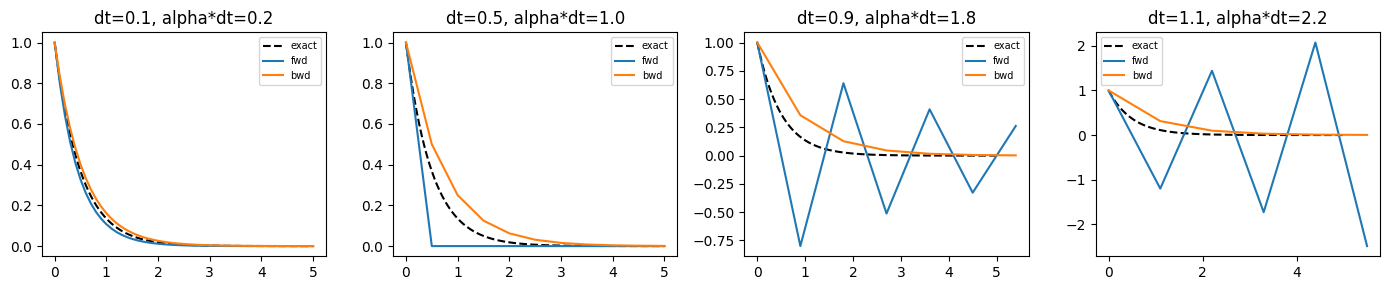

In [6]:
# --- experiment 1: vary dt for fixed alpha ---
# forward euler goes unstable when dt > 2/alpha
alpha = 2.0
dts = [0.1, 0.5, 0.9, 1.1]  # straddle the dt=1 stability boundary

fig, axes = plt.subplots(1, len(dts), figsize=(14, 3))
for ax, dt in zip(axes, dts):
    ts, xs = forward_euler(lambda x, t: linear_rhs(x, t, alpha), x0, dt, T)
    ts_b, xs_b = backward_euler_alpha(alpha, x0, dt, T)
    t_fine = np.linspace(0, T, 300)
    ax.plot(t_fine, exact(t_fine, alpha), 'k--', label='exact')
    ax.plot(ts, xs[:, 0], label='fwd')
    ax.plot(ts_b, xs_b, label='bwd')
    ax.set_title(f'dt={dt}, alpha*dt={alpha*dt:.1f}')
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

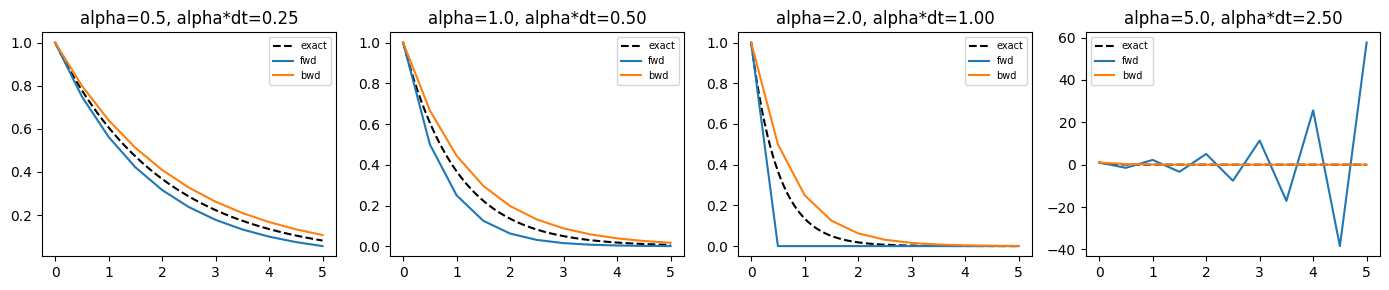

In [7]:
# --- experiment 2: vary alpha for fixed dt ---
dt = 0.5
alphas = [0.5, 1.0, 2.0, 5.0]  # alpha*dt = 0.25, 0.5, 1.0, 2.5

fig, axes = plt.subplots(1, len(alphas), figsize=(14, 3))
for ax, alpha in zip(axes, alphas):
    ts, xs = forward_euler(lambda x, t: linear_rhs(x, t, alpha), x0, dt, T)
    ts_b, xs_b = backward_euler_alpha(alpha, x0, dt, T)
    t_fine = np.linspace(0, T, 300)
    ax.plot(t_fine, exact(t_fine, alpha), 'k--', label='exact')
    ax.plot(ts, xs[:, 0], label='fwd')
    ax.plot(ts_b, xs_b, label='bwd')
    ax.set_title(f'alpha={alpha}, alpha*dt={alpha*dt:.2f}')
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

### 1.10b

Simulate the Lotka-Volterra equations.

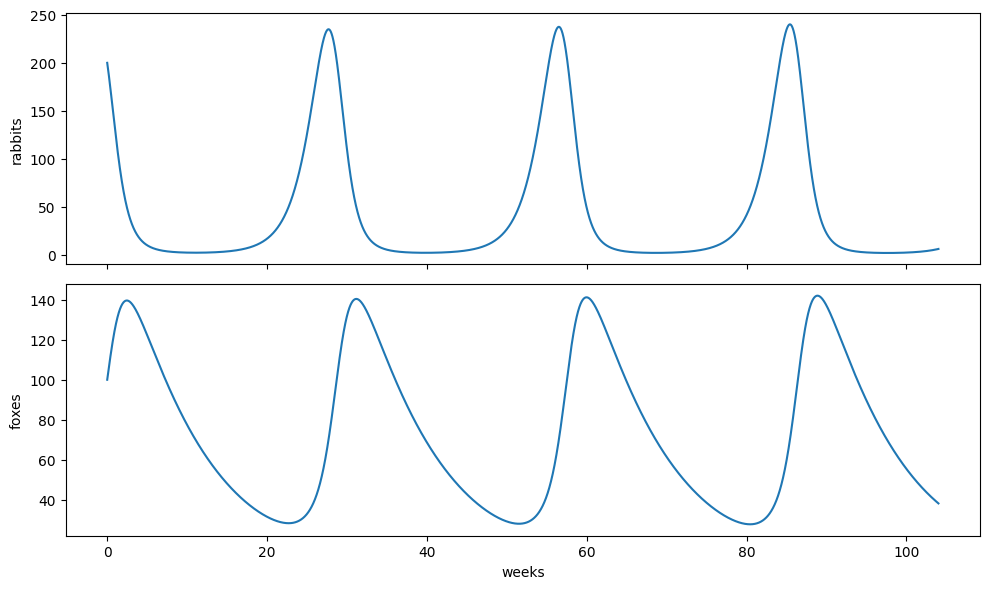

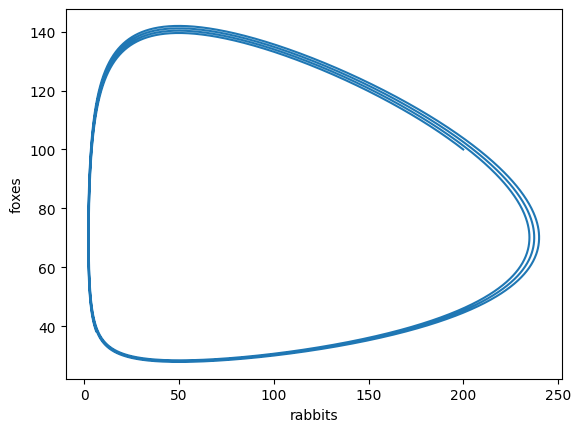

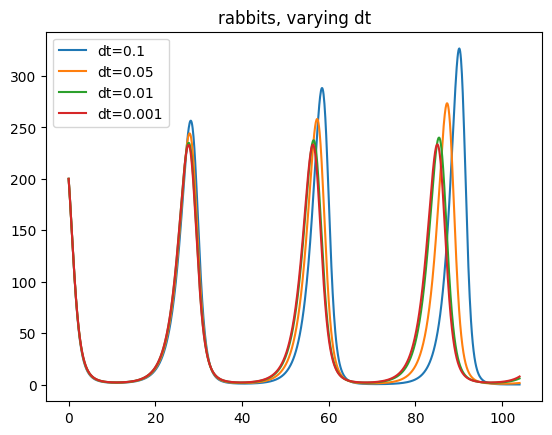

In [8]:
def lv_rhs(y, t, alpha=0.7, beta=0.01, gamma=0.1, delta=0.002):
    R, F = y
    return np.array([
        alpha*R - beta*R*F,
        -gamma*F + delta*R*F
    ])

# run
y0 = np.array([200.0, 100.0])
T = 104.0  # 2 years in weeks
ts, ys = forward_euler(lv_rhs, y0, dt=0.01, T=T)

# plot populations over time
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax1.plot(ts, ys[:, 0], label='rabbits')
ax2.plot(ts, ys[:, 1], label='foxes')
ax1.set_ylabel('rabbits'); ax2.set_ylabel('foxes'); ax2.set_xlabel('weeks')
plt.tight_layout()
plt.show()

# phase portrait
plt.plot(ys[:, 0], ys[:, 1])
plt.xlabel('rabbits'); plt.ylabel('foxes')
plt.show()

# vary dt to show instability
for dt in [0.1, 0.05, 0.01, 0.001]:
    ts, ys = forward_euler(lv_rhs, y0, dt=dt, T=T)
    plt.plot(ts, ys[:, 0], label=f'dt={dt}')
plt.legend(); plt.title('rabbits, varying dt'); plt.show()

## Sheet 2

### 2.6a

Collocation of basic functions with low-degree polynomials.



/var/folders/7_/dyzyr7j12mx5_8rbvq0b52r80000gn/T/ipykernel_23974/2582455687.py:12: RuntimeWarning: divide by zero encountered in divide
  r'$1/(1-x^2)$':   1 / (1 - x_plot**2),


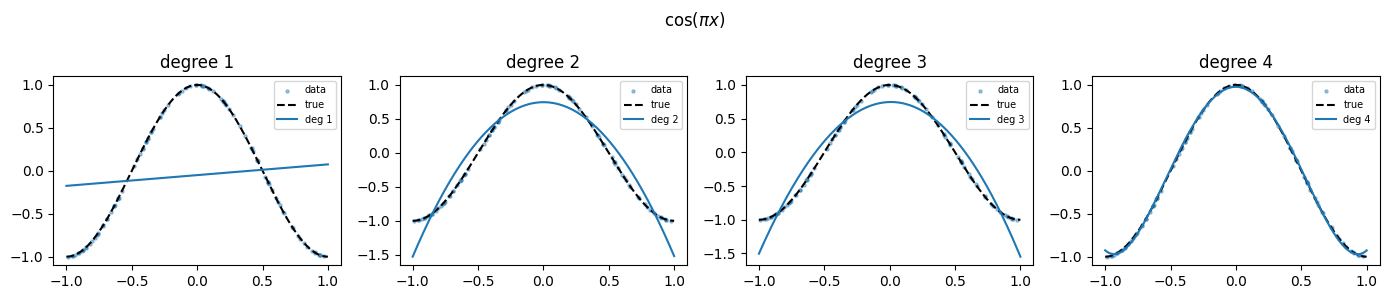

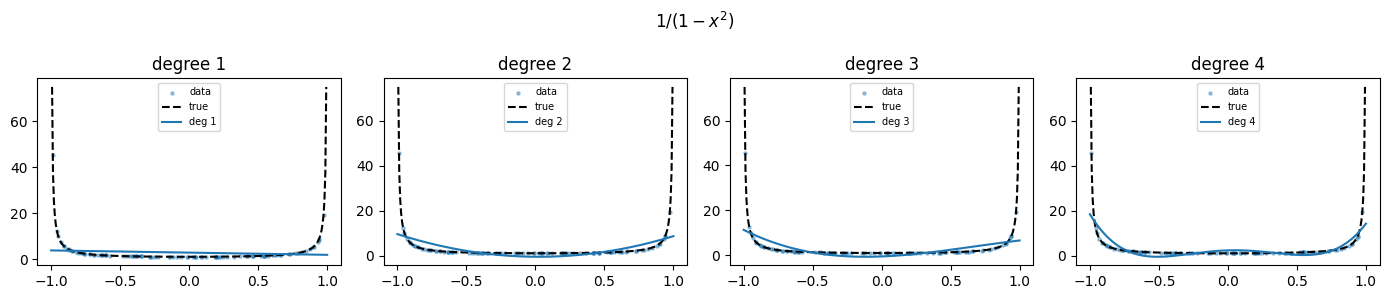

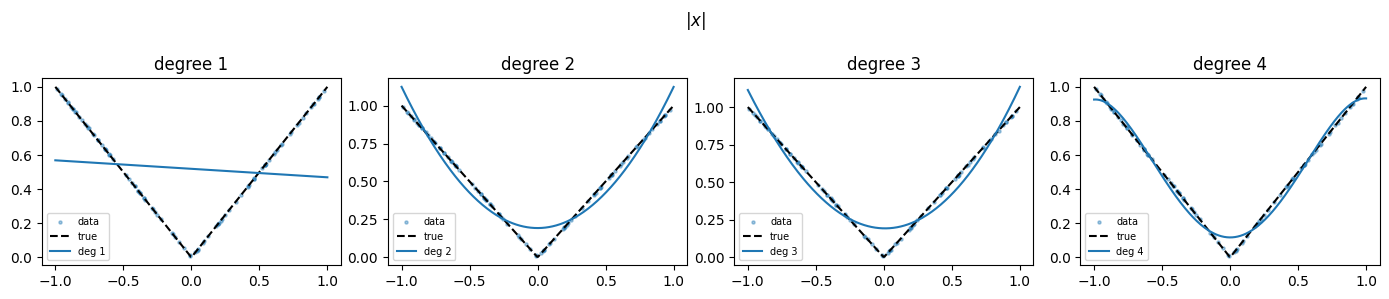

In [9]:
np.random.seed(42)
x = np.random.uniform(-1, 1, 100)
x_plot = np.linspace(-1, 1, 300)

functions = {
    r'$\cos(\pi x)$': np.cos(np.pi * x),
    r'$1/(1-x^2)$':   1 / (1 - x**2),
    r'$|x|$':         np.abs(x),
}
functions_plot = {
    r'$\cos(\pi x)$': np.cos(np.pi * x_plot),
    r'$1/(1-x^2)$':   1 / (1 - x_plot**2),
    r'$|x|$':         np.abs(x_plot),
}

degrees = [1, 2, 3, 4]

for fname, y in functions.items():
    fig, axes = plt.subplots(1, 4, figsize=(14, 3))
    fig.suptitle(fname)
    for ax, deg in zip(axes, degrees):
        coeffs = np.polyfit(x, y, deg)
        y_fit = np.polyval(coeffs, x_plot)
        ax.scatter(x, y, s=5, alpha=0.4, label='data')
        ax.plot(x_plot, functions_plot[fname], 'k--', label='true')
        ax.plot(x_plot, y_fit, label=f'deg {deg}')
        ax.set_title(f'degree {deg}')
        ax.legend(fontsize=7)
    plt.tight_layout()
    plt.show()

### 2.6b

Euler method for $y''=10xy$.

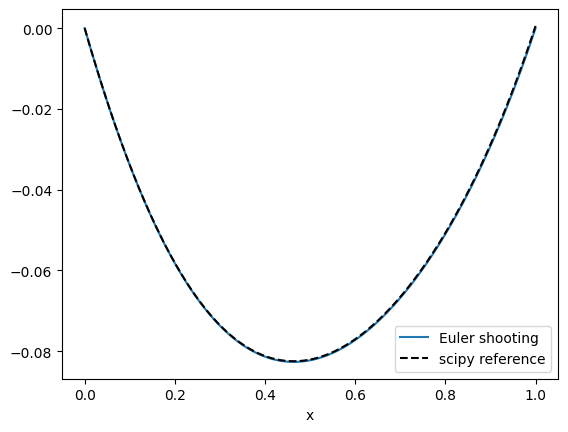

In [13]:
def bvp_rhs_u(y, t):
    # u'' = 10xu + 1, u(0)=0, u'(0)=0
    return np.array([y[1], 10*t*y[0] + 1])

def bvp_rhs_v(y, t):
    # v'' = 10xv, v(0)=0, v'(0)=1
    return np.array([y[1], 10*t*y[0]])

dt = 0.001
T = 1.0

_, u = forward_euler(bvp_rhs_u, np.array([0.0, 0.0]), dt, T)
_, v = forward_euler(bvp_rhs_v, np.array([0.0, 1.0]), dt, T)

# y = u + (0 - u(1))/v(1) * v
c = -u[-1, 0] / v[-1, 0]
ts = np.arange(0, T + dt, dt)
y_sol = u[:, 0] + c * v[:, 0]

sol = solve_ivp(lambda t, y: bvp_rhs_u(y, t), [0, 1], [0, 0], dense_output=True, max_step=0.001)
# this isn't the BVP solution, it's just u -- need the full shooting combination

x_plot = np.linspace(0, 1, 300)
y_ref = sol.sol(x_plot)[0] + c * solve_ivp(
    lambda t, y: bvp_rhs_v(y, t), [0, 1], [0, 1], dense_output=True, max_step=0.001
).sol(x_plot)[0]

plt.plot(ts, y_sol, label='Euler shooting')
plt.plot(x_plot, y_ref, 'k--', label='scipy reference')
plt.xlabel('x'); plt.legend(); plt.show()

### 2.6c

Finite difference errors for simple BVP

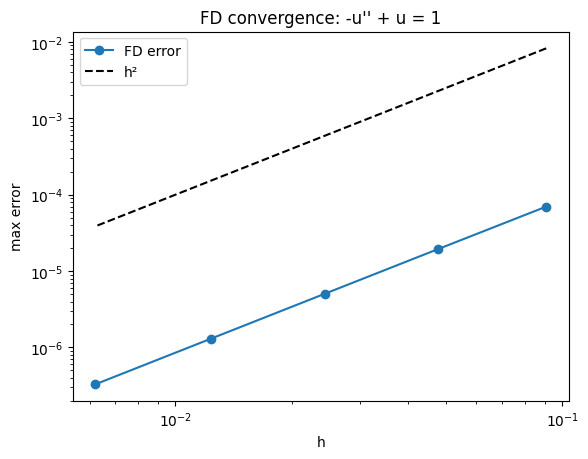

In [14]:
def true_solution(x):
    return 1 - (np.exp(x) + np.exp(1 - x)) / (np.exp(1) + 1)

def fd_solve(n):
    h = 1.0 / (n + 1)
    x = np.linspace(h, 1 - h, n)
    # -(u_{i-1} - 2u_i + u_{i+1})/h^2 + u_i = 1
    diag = 2/h**2 + 1
    off  = -1/h**2
    A = np.diag([diag]*n) + np.diag([off]*(n-1), 1) + np.diag([off]*(n-1), -1)
    b = np.ones(n)
    u = np.linalg.solve(A, b)
    err = np.max(np.abs(u - true_solution(x)))
    return h, err

ns = [10, 20, 40, 80, 160]
hs, errs = zip(*[fd_solve(n) for n in ns])

plt.loglog(hs, errs, 'o-', label='FD error')
plt.loglog(hs, [h**2 for h in hs], 'k--', label='h²')
plt.xlabel('h'); plt.ylabel('max error'); plt.legend()
plt.title('FD convergence: -u\'\' + u = 1')
plt.show()

## Sheet 3

## 3.7a

Approximating $e^x$ via collocation

/var/folders/7_/dyzyr7j12mx5_8rbvq0b52r80000gn/T/ipykernel_23974/4035489937.py:15: RuntimeWarning: divide by zero encountered in reciprocal
  A[:, j] = j * x**(j-1) - x**j  # phi_j' - phi_j
/var/folders/7_/dyzyr7j12mx5_8rbvq0b52r80000gn/T/ipykernel_23974/4035489937.py:15: RuntimeWarning: invalid value encountered in multiply
  A[:, j] = j * x**(j-1) - x**j  # phi_j' - phi_j


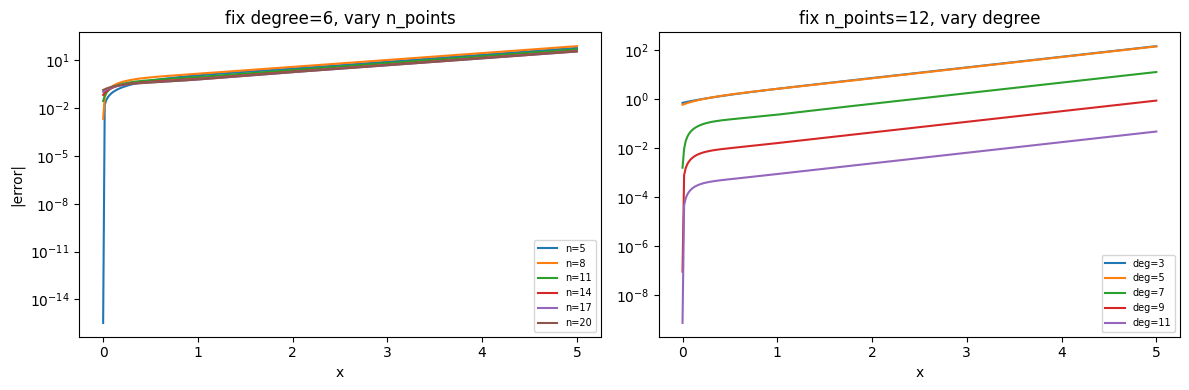

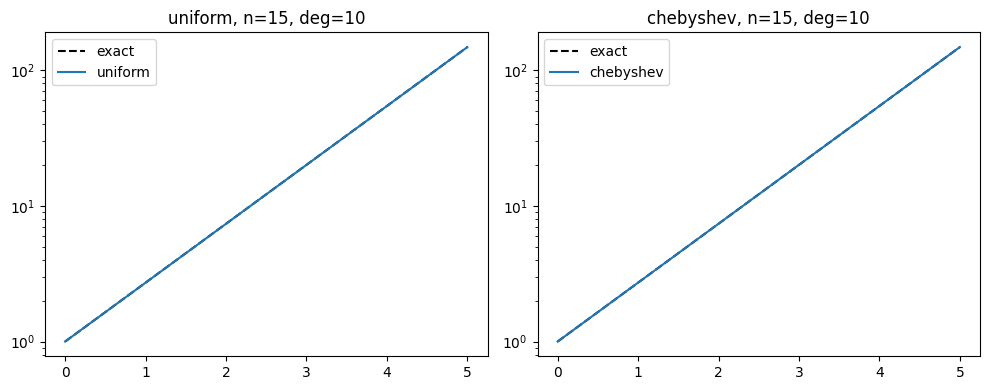

In [17]:
# ============ Q7a: Polynomial Collocation on y' - y = 0 ============

def poly_collocation(n_points, degree, distribution='uniform'):
    if distribution == 'uniform':
        x = np.linspace(0, 5, n_points)
    else:  # chebyshev
        k = np.arange(1, n_points + 1)
        x = 2.5 + 2.5 * np.cos((2*k - 1) * np.pi / (2*n_points))
    
    # basis: phi_j(x) = x^j, phi_j'(x) = j*x^(j-1)
    # residual: y' - y = 0 at collocation points
    # y(0) = 1 as extra condition -> replace first row
    A = np.zeros((n_points, degree + 1))
    for j in range(degree + 1):
        A[:, j] = j * x**(j-1) - x**j  # phi_j' - phi_j
    
    b = np.zeros(n_points)
    # enforce y(0) = 1 via first row
    A[0, :] = np.array([0**j for j in range(degree + 1)])
    b[0] = 1.0
    
    coeffs, _, _, _ = np.linalg.lstsq(A, b, rcond=None)
    
    x_plot = np.linspace(0, 5, 300)
    y_approx = np.polyval(coeffs[::-1], x_plot)
    return x_plot, y_approx

x_plot = np.linspace(0, 5, 300)
exact = np.exp(x_plot)

# --- experiment 1: fix degree, vary n_points ---
degree = 6
n_points_list = [5, 8, 11, 14, 17, 20]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for n in n_points_list:
    _, yp = poly_collocation(n, degree, 'uniform')
    axes[0].semilogy(x_plot, np.abs(yp - exact), label=f'n={n}')
axes[0].set_title(f'fix degree={degree}, vary n_points')
axes[0].legend(fontsize=7); axes[0].set_xlabel('x'); axes[0].set_ylabel('|error|')

# --- experiment 2: fix n_points, vary degree ---
n_points = 12
degrees = [3, 5, 7, 9, 11]

for d in degrees:
    _, yp = poly_collocation(n_points, d, 'uniform')
    axes[1].semilogy(x_plot, np.abs(yp - exact), label=f'deg={d}')
axes[1].set_title(f'fix n_points={n_points}, vary degree')
axes[1].legend(fontsize=7); axes[1].set_xlabel('x')
plt.tight_layout(); plt.show()

# --- experiment 3: fix n_points and degree, vary distribution ---
n_points, degree = 15, 10
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for dist, ax in zip(['uniform', 'chebyshev'], axes):
    _, yp = poly_collocation(n_points, degree, dist)
    ax.plot(x_plot, exact, 'k--', label='exact')
    ax.plot(x_plot, yp, label=dist)
    ax.semilogy() 
    ax.set_title(f'{dist}, n={n_points}, deg={degree}')
    ax.legend()
plt.tight_layout(); plt.show()

### 3.7b

Approximation with NN

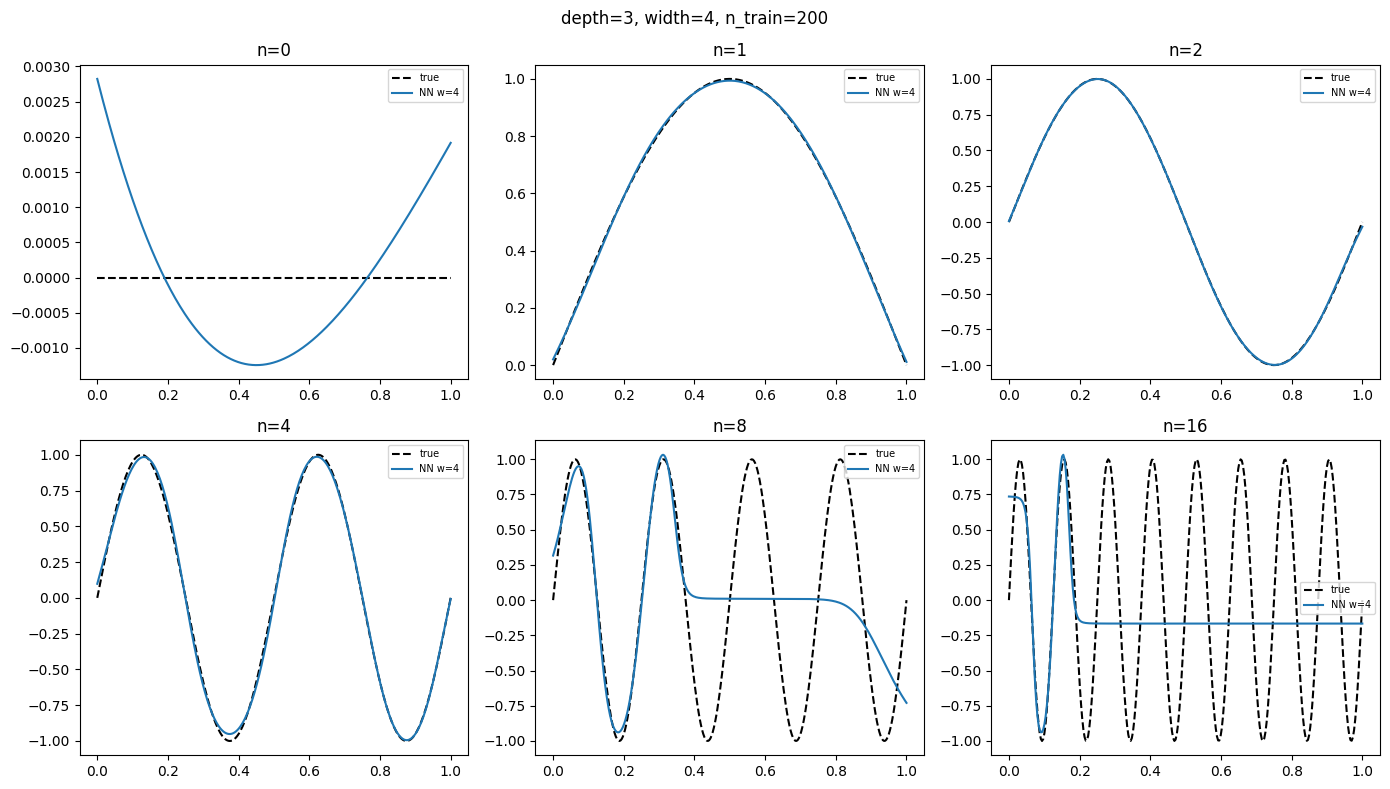

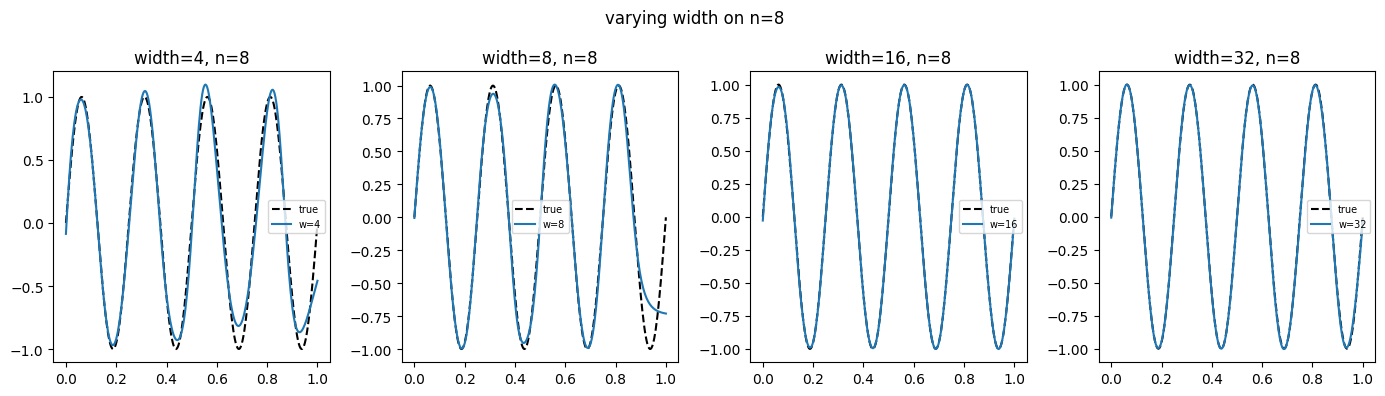

In [18]:
# ============ Q7b: NN fitting sin(n*pi*x) ============

class MLP(nn.Module):
    def __init__(self, width):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, width), nn.Tanh(),
            nn.Linear(width, width), nn.Tanh(),
            nn.Linear(width, width), nn.Tanh(),
            nn.Linear(width, 1)
        )
    def forward(self, x):
        return self.net(x)

def train_nn(n_freq, n_train, width=4, n_epochs=5000):
    x = torch.rand(n_train, 1)
    y = torch.sin(n_freq * torch.pi * x)
    model = MLP(width)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    for _ in range(n_epochs):
        opt.zero_grad()
        loss = ((model(x) - y)**2).mean()
        loss.backward()
        opt.step()
    return model

freqs = [0, 1, 2, 4, 8, 16]
n_train = 200
x_plot = torch.linspace(0, 1, 300).unsqueeze(1)

# vary frequency, fixed width=4
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, n in zip(axes.flat, freqs):
    model = train_nn(n, n_train, width=4)
    with torch.no_grad():
        y_pred = model(x_plot).numpy()
    ax.plot(x_plot.numpy(), np.sin(n * np.pi * x_plot.numpy()), 'k--', label='true')
    ax.plot(x_plot.numpy(), y_pred, label='NN w=4')
    ax.set_title(f'n={n}'); ax.legend(fontsize=7)
plt.suptitle('depth=3, width=4, n_train=200'); plt.tight_layout(); plt.show()

# vary width for high frequency
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, w in zip(axes, [4, 8, 16, 32]):
    model = train_nn(8, n_train, width=w)
    with torch.no_grad():
        y_pred = model(x_plot).numpy()
    ax.plot(x_plot.numpy(), np.sin(8 * np.pi * x_plot.numpy()), 'k--', label='true')
    ax.plot(x_plot.numpy(), y_pred, label=f'w={w}')
    ax.set_title(f'width={w}, n=8'); ax.legend(fontsize=7)
plt.suptitle('varying width on n=8'); plt.tight_layout(); plt.show()

## Sheet 4

### 4.8a

Investigate ODEs on PINNs of different widths or depths

In [ ]:
# ============================================================
# Shared MLP
# ============================================================

class MLP(nn.Module):
    def __init__(self, width, depth, in_dim=1, out_dim=1):
        super().__init__()
        layers = [nn.Linear(in_dim, width), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(width, width), nn.Tanh()]
        layers += [nn.Linear(width, out_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

def grad(u, x):
    return torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u),
                               create_graph=True)[0]

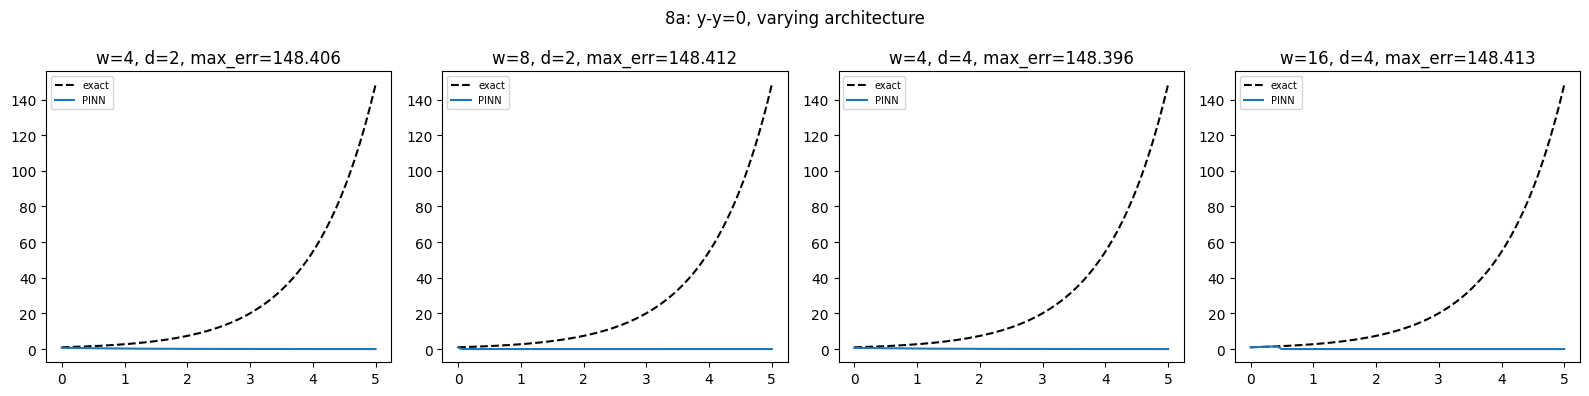

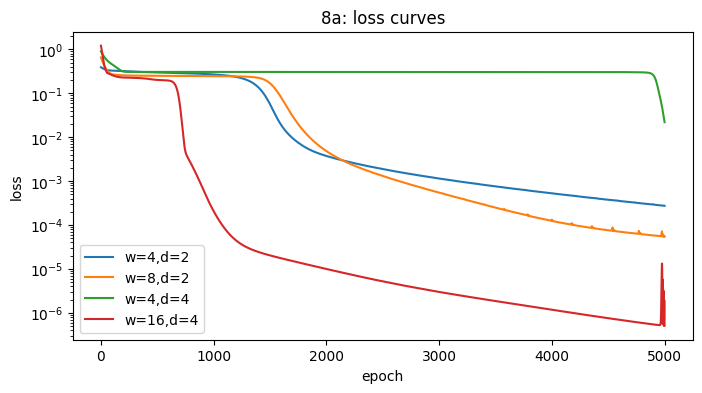

In [ ]:
# ============================================================
# 8a: y' - y = 0, y(0) = 1
# ============================================================

def pinn_loss_8a(model, x_int, x_bc):
    x_int.requires_grad_(True)
    y = model(x_int)
    dy = grad(y, x_int)
    residual = (dy - y).pow(2).mean()
    bc = (model(x_bc) - 1.0).pow(2).mean()
    return residual + bc

def run_8a(width, depth, n_int=100, n_epochs=5000, lr=1e-3):
    model = MLP(width, depth)
    x_int = torch.rand(n_int, 1) * 5.0
    x_bc  = torch.zeros(1, 1)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    for _ in range(n_epochs):
        opt.zero_grad()
        loss = pinn_loss_8a(model, x_int, x_bc)
        loss.backward()
        opt.step()
        losses.append(loss.item())
    return model, losses

# vary width and depth
configs = [(4,2), (8,2), (4,4), (16,4)]
x_plot = torch.linspace(0, 5, 200).unsqueeze(1)
exact = torch.exp(x_plot)

fig, axes = plt.subplots(1, len(configs), figsize=(16, 4))
for ax, (w, d) in zip(axes, configs):
    model, losses = run_8a(w, d)
    with torch.no_grad():
        y_pred = model(x_plot)
    err = (y_pred - exact).abs().max().item()
    ax.plot(x_plot.numpy(), exact.numpy(), 'k--', label='exact')
    ax.plot(x_plot.numpy(), y_pred.numpy(), label=f'PINN')
    ax.set_title(f'w={w}, d={d}, max_err={err:.3f}')
    ax.legend(fontsize=7)
plt.suptitle('8a: y-y=0, varying architecture')
plt.tight_layout(); plt.show()

# loss curves
fig, ax = plt.subplots(figsize=(8, 4))
for w, d in configs:
    _, losses = run_8a(w, d)
    ax.semilogy(losses, label=f'w={w},d={d}')
ax.legend(); ax.set_xlabel('epoch'); ax.set_ylabel('loss')
ax.set_title('8a: loss curves'); plt.show()

### 4.8b

Comparison of gradient descent, rank1 BFGS, and rank2 BFGS

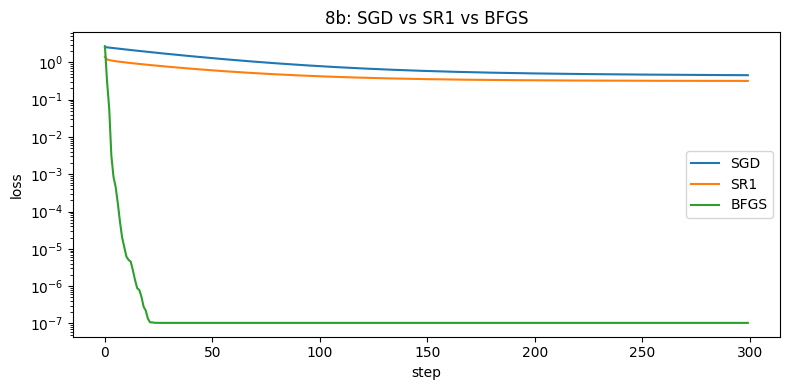

In [23]:
# ============================================================
# SR1 optimiser (rank-1 quasi-Newton)
# stores full inverse Hessian approx -- only feasible for small nets
# ============================================================

class SR1Optimiser(torch.optim.Optimizer):
    def __init__(self, params, lr=0.1):
        super().__init__(params, dict(lr=lr))
        self._gs = {}  # global state

    def _flat_params(self):
        return torch.cat([p.data.flatten()
                          for g in self.param_groups for p in g['params']])

    def _flat_grads(self):
        return torch.cat([p.grad.flatten()
                          for g in self.param_groups for p in g['params']
                          if p.grad is not None])

    def _set_params(self, flat):
        idx = 0
        for group in self.param_groups:
            for p in group['params']:
                n = p.numel()
                p.data.copy_(flat[idx:idx+n].reshape(p.shape))
                idx += n

    def step(self, closure):
        with torch.enable_grad():
            loss = closure()

        fp = self._flat_params()
        fg = self._flat_grads()
        n  = fp.shape[0]
        gs = self._gs

        if 'H' not in gs:
            gs['H']  = torch.eye(n)
            gs['fp'] = fp.clone()
            gs['fg'] = fg.clone()
        else:
            s    = fp - gs['fp']
            y    = fg - gs['fg']
            Hy   = gs['H'] @ y
            v    = s - Hy
            denom = v @ y
            # skip update if denominator too small (SR1 instability)
            if denom.abs().item() > 1e-10 * v.norm().item() * y.norm().item():
                gs['H'] = gs['H'] + torch.outer(v, v) / denom
            gs['fp'] = fp.clone()
            gs['fg'] = fg.clone()

        direction = -(gs['H'] @ fg)
        lr = self.param_groups[0]['lr']
        self._set_params(fp + lr * direction)
        return loss


# ============================================================
# 8b: GD vs SR1 vs BFGS
# ============================================================

x_int = torch.rand(100, 1) * 5.0
x_bc  = torch.zeros(1, 1)

def run_optimiser(opt_name, n_steps=300):
    model = MLP(8, 3)

    if opt_name == 'SGD':
        opt = torch.optim.SGD(model.parameters(), lr=1e-3)
    elif opt_name == 'SR1':
        opt = SR1Optimiser(model.parameters(), lr=0.01)
    elif opt_name == 'BFGS':
        opt = torch.optim.LBFGS(model.parameters(), lr=0.1,
                                 history_size=10,
                                 line_search_fn='strong_wolfe')

    losses = []
    for _ in range(n_steps):
        if opt_name in ('SR1', 'BFGS'):
            def closure():
                opt.zero_grad()
                loss = pinn_loss_8a(model, x_int, x_bc)
                loss.backward()
                return loss
            loss = opt.step(closure)
        else:
            opt.zero_grad()
            loss = pinn_loss_8a(model, x_int, x_bc)
            loss.backward()
            opt.step()
        losses.append(loss.item())
    return model, losses

fig, ax = plt.subplots(figsize=(8, 4))
for name in ['SGD', 'SR1', 'BFGS']:
    model, losses = run_optimiser(name)
    ax.semilogy(losses, label=name)
ax.legend(); ax.set_xlabel('step'); ax.set_ylabel('loss')
ax.set_title('8b: SGD vs SR1 vs BFGS'); plt.tight_layout(); plt.show()

### 4.8c

Limiting behaviour of diffusion term

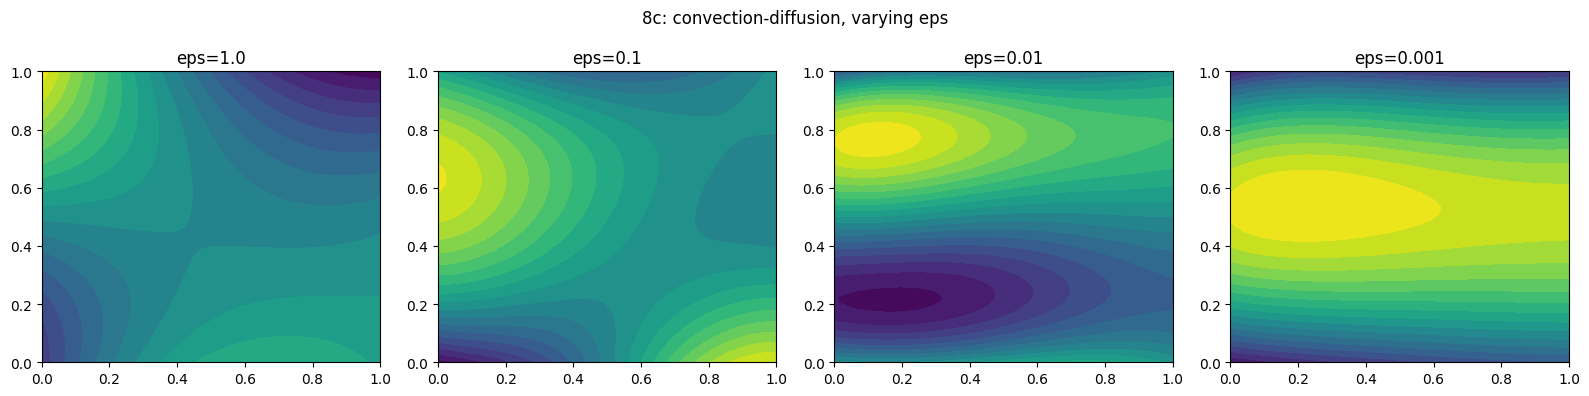

In [ ]:
# ============================================================
# 8c: -eps*∆u + b·∇u = 0 on (0,1)^2, b=[1,0]
# BCs: u(x,0)=0, u(x,1)=1, u(0,y)=sign(y-0.5), du/dx(1,y)=0
# ============================================================

def pinn_loss_8c(model, xy_int, bc_pts, eps):
    xy_int.requires_grad_(True)
    u = model(xy_int)
    du = grad(u, xy_int)
    du_x = du[:, 0:1]
    du_y = du[:, 1:2]
    du_xx = grad(du_x, xy_int)[:, 0:1]
    du_yy = grad(du_y, xy_int)[:, 1:2]
    residual = (-eps * (du_xx + du_yy) + du_x).pow(2).mean()

    x_b, y_b, u_b, neumann_mask = bc_pts
    xy_b = torch.stack([x_b, y_b], dim=1).requires_grad_(True)
    u_pred = model(xy_b)
    du_b = grad(u_pred, xy_b)
    du_bx = du_b[:, 0:1]

    dirichlet_loss = ((u_pred[~neumann_mask] - u_b[~neumann_mask])**2).mean()
    neumann_loss   = (du_bx[neumann_mask]**2).mean()

    return residual + dirichlet_loss + neumann_loss

def make_bc_8c(n=200):
    # u(x,0)=0: bottom
    x0 = torch.rand(n); y0 = torch.zeros(n); u0 = torch.zeros(n)
    # u(x,1)=1: top
    x1 = torch.rand(n); y1 = torch.ones(n);  u1 = torch.ones(n)
    # u(0,y)=sign(y-0.5): left
    xl = torch.zeros(n); yl = torch.rand(n);  ul = torch.sign(yl - 0.5)
    # du/dx(1,y)=0: right (Neumann)
    xr = torch.ones(n);  yr = torch.rand(n);  ur = torch.zeros(n)

    x = torch.cat([x0, x1, xl, xr])
    y = torch.cat([y0, y1, yl, yr])
    u = torch.cat([u0, u1, ul, ur])
    neumann = torch.cat([torch.zeros(3*n), torch.ones(n)]).bool()
    return x, y, u, neumann

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, eps in zip(axes, [1.0, 0.1, 0.01, 0.001]):
    model = MLP(16, 4, in_dim=2)
    xy_int = torch.rand(500, 2)
    bc_pts = make_bc_8c()
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    for _ in range(5000):
        opt.zero_grad()
        loss = pinn_loss_8c(model, xy_int, bc_pts, eps)
        loss.backward()
        opt.step()

    xg, yg = torch.meshgrid(torch.linspace(0,1,50), torch.linspace(0,1,50), indexing='ij')
    xy_grid = torch.stack([xg.flatten(), yg.flatten()], dim=1)
    with torch.no_grad():
        u_grid = model(xy_grid).reshape(50, 50)
    ax.contourf(xg.numpy(), yg.numpy(), u_grid.numpy(), levels=20)
    ax.set_title(f'eps={eps}')
    ax.xlabel("x")
    ax.ylabel("y")

    
plt.suptitle('8c: convection-diffusion, varying eps')
plt.tight_layout(); plt.show()

### 4.8d

PINN solutions to the cracked disc ODE

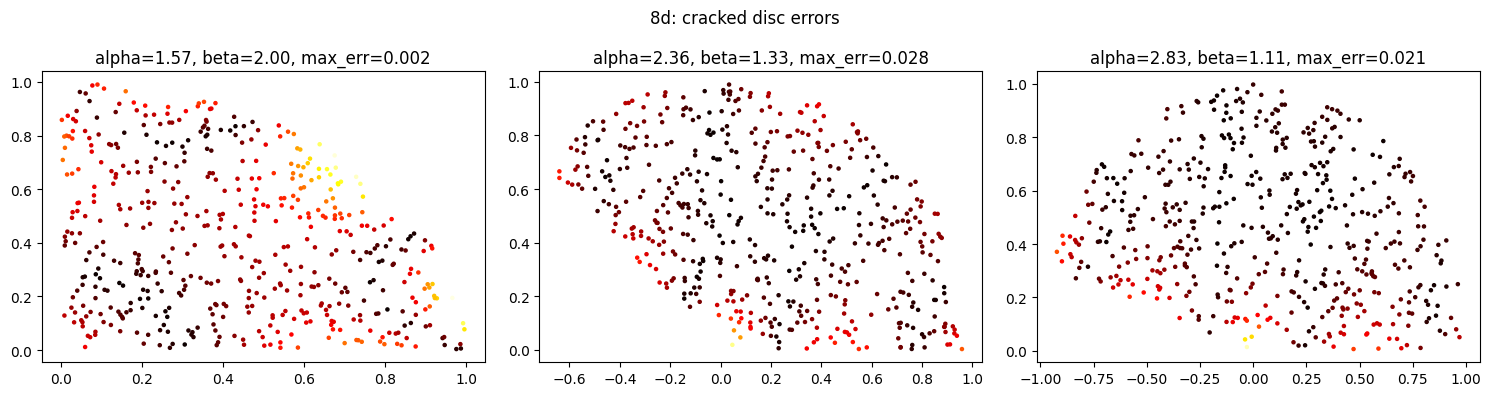

In [ ]:
# ============================================================
# 8d: cracked disc, -∆u=0, u = r^beta * sin(pi*theta/alpha)
# beta = pi/alpha
# ============================================================

def polar_to_cart(r, theta):
    return r * torch.cos(theta), r * torch.sin(theta)

def true_sol_8d(r, theta, alpha):
    beta = torch.pi / alpha
    return r**beta * torch.sin(torch.pi * theta / alpha)


# ============================================================
# PINN loss function (cracked disc yields instability)
# ============================================================
def pinn_loss_8d(model, xy_int, xy_bc, u_bc):
    xy_int.requires_grad_(True)
    u = model(xy_int)
    du = grad(u, xy_int)
    du_x = du[:, 0:1]
    du_y = du[:, 1:2]
    du_xx = grad(du_x, xy_int)[:, 0:1]
    du_yy = grad(du_y, xy_int)[:, 1:2]
    residual = (du_xx + du_yy).pow(2).mean()
    bc_loss  = (model(xy_bc) - u_bc).pow(2).mean()
    return residual + bc_loss

def sample_cracked_disc(alpha, n=300):
    # interior: polar coords (r in (0,1), theta in (0, alpha))
    r     = torch.rand(n) ** 0.5  # sqrt for uniform area
    theta = torch.rand(n) * alpha
    x, y  = polar_to_cart(r, theta)
    xy_int = torch.stack([x, y], dim=1)

    # boundary
    n_bc = 100
    r_b  = torch.ones(n_bc)
    th_b = torch.rand(n_bc) * alpha
    xb, yb = polar_to_cart(r_b, th_b)
    # also the two straight edges: theta=0 and theta=alpha
    r_e  = torch.rand(2*n_bc)
    th_e = torch.cat([torch.zeros(n_bc), torch.full((n_bc,), alpha)])
    xe, ye = polar_to_cart(r_e, th_e)

    xbc   = torch.cat([xb, xe])
    ybc   = torch.cat([yb, ye])
    r_all = torch.cat([r_b, r_e])
    t_all = torch.cat([th_b, th_e])
    u_bc  = true_sol_8d(r_all, t_all, torch.tensor(alpha)).unsqueeze(1)
    xy_bc = torch.stack([xbc, ybc], dim=1)
    return xy_int, xy_bc, u_bc

# sample alpha values in [0,pi)
alphas = [0.5 * torch.pi, 0.75 * torch.pi, 0.9 * torch.pi]
fig, axes = plt.subplots(1, len(alphas), figsize=(15, 4))
for ax, alpha_val in zip(axes, alphas):
    alpha = float(alpha_val)
    beta  = torch.pi / alpha_val

    model = MLP(16, 4, in_dim=2)
    xy_int, xy_bc, u_bc = sample_cracked_disc(alpha)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    for _ in range(5000):
        opt.zero_grad()
        loss = pinn_loss_8d(model, xy_int, xy_bc, u_bc)
        loss.backward()
        opt.step()

    # evaluate error on grid inside domain
    r_t   = torch.rand(500) ** 0.5
    th_t  = torch.rand(500) * alpha
    xt, yt = polar_to_cart(r_t, th_t)
    xy_t  = torch.stack([xt, yt], dim=1)
    u_true = true_sol_8d(r_t, th_t, torch.tensor(alpha)).unsqueeze(1)
    with torch.no_grad():
        u_pred = model(xy_t)
    err = (u_pred - u_true).abs().max().item()

    ax.scatter(xt.numpy(), yt.numpy(), c=(u_pred - u_true).abs().detach().numpy().flatten(),
               cmap='hot', s=5)
    ax.set_title(f'alpha={alpha:.2f}, beta={float(beta):.2f}, max_err={err:.3f}')
plt.suptitle('8d: cracked disc errors')
plt.tight_layout(); plt.show()

/var/folders/7_/dyzyr7j12mx5_8rbvq0b52r80000gn/T/ipykernel_83664/3101652214.py:76: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im0 = axes[0, col].pcolormesh(X.numpy(), Y.numpy(), u_pred.numpy(),
/var/folders/7_/dyzyr7j12mx5_8rbvq0b52r80000gn/T/ipykernel_83664/3101652214.py:83: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im1 = axes[1, col].pcolormesh(X.numpy(), Y.numpy(), err.numpy(),


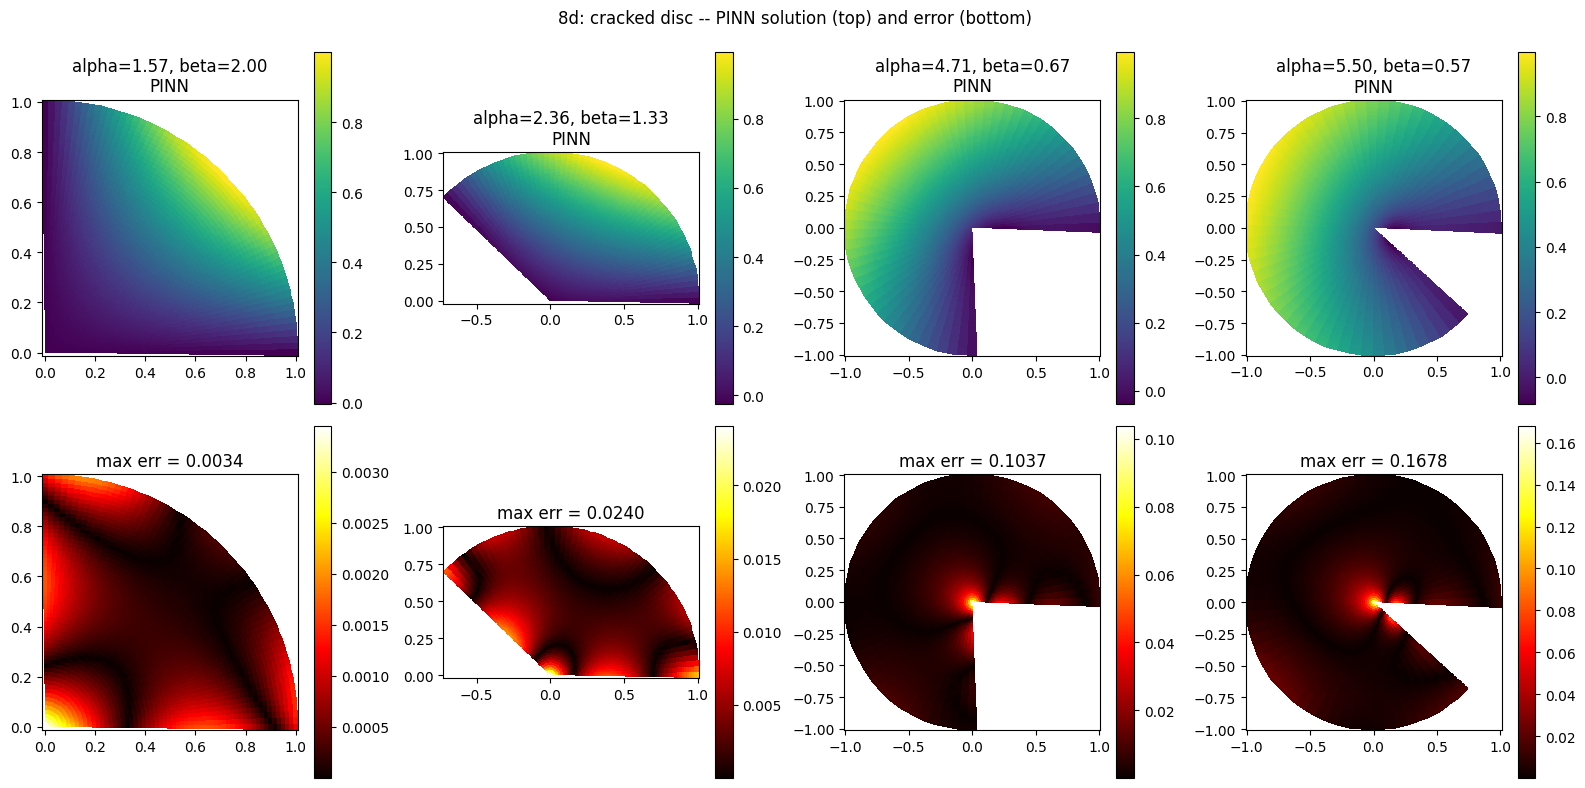

In [5]:
def polar_to_cart(r, theta):
    return r * torch.cos(theta), r * torch.sin(theta)

def true_sol_8d(r, theta, alpha):
    beta = torch.pi / alpha
    return r**beta * torch.sin(torch.pi * theta / alpha)

def grad(u, x):
    return torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]

def pinn_loss_8d(model, xy_int, xy_bc, u_bc):
    xy_int.requires_grad_(True)
    u = model(xy_int)
    du = grad(u, xy_int)
    u_xx = grad(du[:, 0:1], xy_int)[:, 0:1]
    u_yy = grad(du[:, 1:2], xy_int)[:, 1:2]
    residual = (u_xx + u_yy).pow(2).mean()
    bc = (model(xy_bc) - u_bc).pow(2).mean()
    return residual + bc

def sample_cracked_disc(alpha, n_int=500, n_bc=200):
    r = torch.rand(n_int) ** 0.5
    theta = torch.rand(n_int) * alpha
    x, y = polar_to_cart(r, theta)
    xy_int = torch.stack([x, y], dim=1)

    n_face = n_bc // 3
    # arc r=1
    th_arc = torch.rand(n_face) * alpha
    x_arc, y_arc = polar_to_cart(torch.ones(n_face), th_arc)
    # straight edge theta=0
    r_e0 = torch.rand(n_face)
    x_e0, y_e0 = polar_to_cart(r_e0, torch.zeros(n_face))
    # straight edge theta=alpha
    r_ea = torch.rand(n_face)
    x_ea, y_ea = polar_to_cart(r_ea, torch.full((n_face,), alpha))

    x_b = torch.cat([x_arc, x_e0, x_ea])
    y_b = torch.cat([y_arc, y_e0, y_ea])
    r_b = torch.cat([torch.ones(n_face), r_e0, r_ea])
    t_b = torch.cat([th_arc, torch.zeros(n_face), torch.full((n_face,), alpha)])
    u_bc = true_sol_8d(r_b, t_b, torch.tensor(alpha)).unsqueeze(1)
    xy_bc = torch.stack([x_b, y_b], dim=1)
    return xy_int, xy_bc, u_bc

alphas = [torch.pi / 2, 3 * torch.pi / 4, 3 * torch.pi / 2, 7 * torch.pi / 4]
fig, axes = plt.subplots(2, len(alphas), figsize=(4*len(alphas), 8))

for col, alpha_val in enumerate(alphas):
    alpha = float(alpha_val)
    beta  = float(torch.pi / alpha_val)

    model = MLP(16, 4, in_dim=2)
    xy_int, xy_bc, u_bc = sample_cracked_disc(alpha)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    for _ in range(8000):
        opt.zero_grad()
        loss = pinn_loss_8d(model, xy_int, xy_bc, u_bc)
        loss.backward()
        opt.step()

    # polar mesh for visualisation
    n_r, n_th = 60, 60
    r_grid  = torch.linspace(0.01, 1.0, n_r)
    th_grid = torch.linspace(0, alpha, n_th)
    R, TH   = torch.meshgrid(r_grid, th_grid, indexing='ij')
    X = R * torch.cos(TH)
    Y = R * torch.sin(TH)
    xy_grid = torch.stack([X.flatten(), Y.flatten()], dim=1)
    with torch.no_grad():
        u_pred = model(xy_grid).reshape(n_r, n_th)
    u_true = true_sol_8d(R, TH, torch.tensor(alpha))
    err = (u_pred - u_true).abs()

    # row 0: PINN solution
    im0 = axes[0, col].pcolormesh(X.numpy(), Y.numpy(), u_pred.numpy(),
                                    shading='auto', cmap='viridis')
    plt.colorbar(im0, ax=axes[0, col])
    axes[0, col].set_aspect('equal')
    axes[0, col].set_title(f'alpha={alpha:.2f}, beta={beta:.2f}\nPINN')

    # row 1: error
    im1 = axes[1, col].pcolormesh(X.numpy(), Y.numpy(), err.numpy(),
                                    shading='auto', cmap='hot')
    plt.colorbar(im1, ax=axes[1, col])
    axes[1, col].set_aspect('equal')
    axes[1, col].set_title(f'max err = {err.max().item():.4f}')

plt.suptitle('8d: cracked disc -- PINN solution (top) and error (bottom)')
plt.tight_layout(); plt.show()

## Sheet 5

### 5.5a: Approximating heat equation

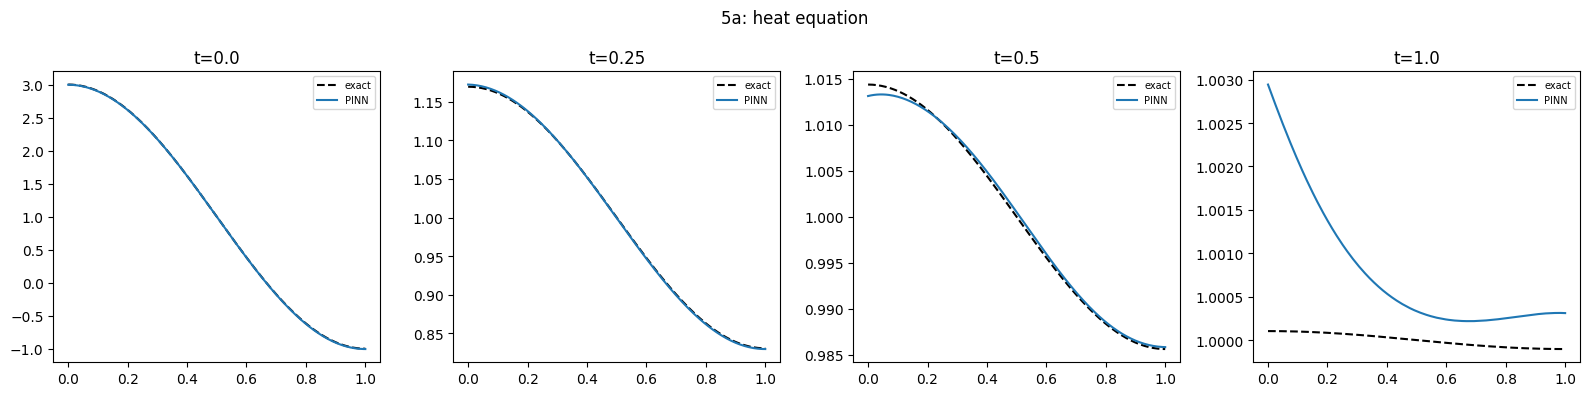

In [6]:
# ============================================================
# 5a: heat u_t - u_xx = 0 on (0,1)x(0,T), Neumann BCs
# IC: u(x,0) = 1 + 2cos(pi*x)
# exact: u(x,t) = 1 + 2cos(pi*x)*exp(-pi^2 * t)
# ============================================================

T = 1.0
def exact_5a(x, t):
    return 1 + 2 * torch.cos(torch.pi * x) * torch.exp(-torch.pi**2 * t)

def pinn_loss_5a(model, xt_int, xt_ic, xt_left, xt_right):
    xt_int.requires_grad_(True)
    u = model(xt_int)
    du = grad(u, xt_int)
    u_t  = du[:, 1:2]
    u_x  = du[:, 0:1]
    u_xx = grad(u_x, xt_int)[:, 0:1]
    pde  = (u_t - u_xx).pow(2).mean()

    u_ic_pred = model(xt_ic)
    u_ic_true = exact_5a(xt_ic[:, 0:1], torch.zeros_like(xt_ic[:, 0:1]))
    ic = (u_ic_pred - u_ic_true).pow(2).mean()

    xt_left.requires_grad_(True)
    u_left  = model(xt_left)
    ux_left = grad(u_left, xt_left)[:, 0:1]
    xt_right.requires_grad_(True)
    u_right  = model(xt_right)
    ux_right = grad(u_right, xt_right)[:, 0:1]
    neumann = ux_left.pow(2).mean() + ux_right.pow(2).mean()

    return pde + ic + neumann

n = 500
xt_int   = torch.stack([torch.rand(n), torch.rand(n) * T], dim=1)
xt_ic    = torch.stack([torch.rand(n), torch.zeros(n)], dim=1)
xt_left  = torch.stack([torch.zeros(n), torch.rand(n) * T], dim=1)
xt_right = torch.stack([torch.ones(n),  torch.rand(n) * T], dim=1)

model_5a = MLP(16, 4, in_dim=2)
opt = torch.optim.Adam(model_5a.parameters(), lr=1e-3)
for _ in range(8000):
    opt.zero_grad()
    loss = pinn_loss_5a(model_5a, xt_int, xt_ic, xt_left, xt_right)
    loss.backward()
    opt.step()

x_plot = torch.linspace(0, 1, 200).unsqueeze(1)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, t_val in zip(axes, [0.0, 0.25, 0.5, 1.0]):
    t_plot = torch.full_like(x_plot, t_val)
    xt = torch.cat([x_plot, t_plot], dim=1)
    with torch.no_grad():
        u_pred = model_5a(xt)
    u_true = exact_5a(x_plot, t_plot)
    ax.plot(x_plot.numpy(), u_true.numpy(), 'k--', label='exact')
    ax.plot(x_plot.numpy(), u_pred.numpy(), label='PINN')
    ax.set_title(f't={t_val}'); ax.legend(fontsize=7)
plt.suptitle('5a: heat equation'); plt.tight_layout(); plt.show()

### 5.5b: Advection with small viscosity

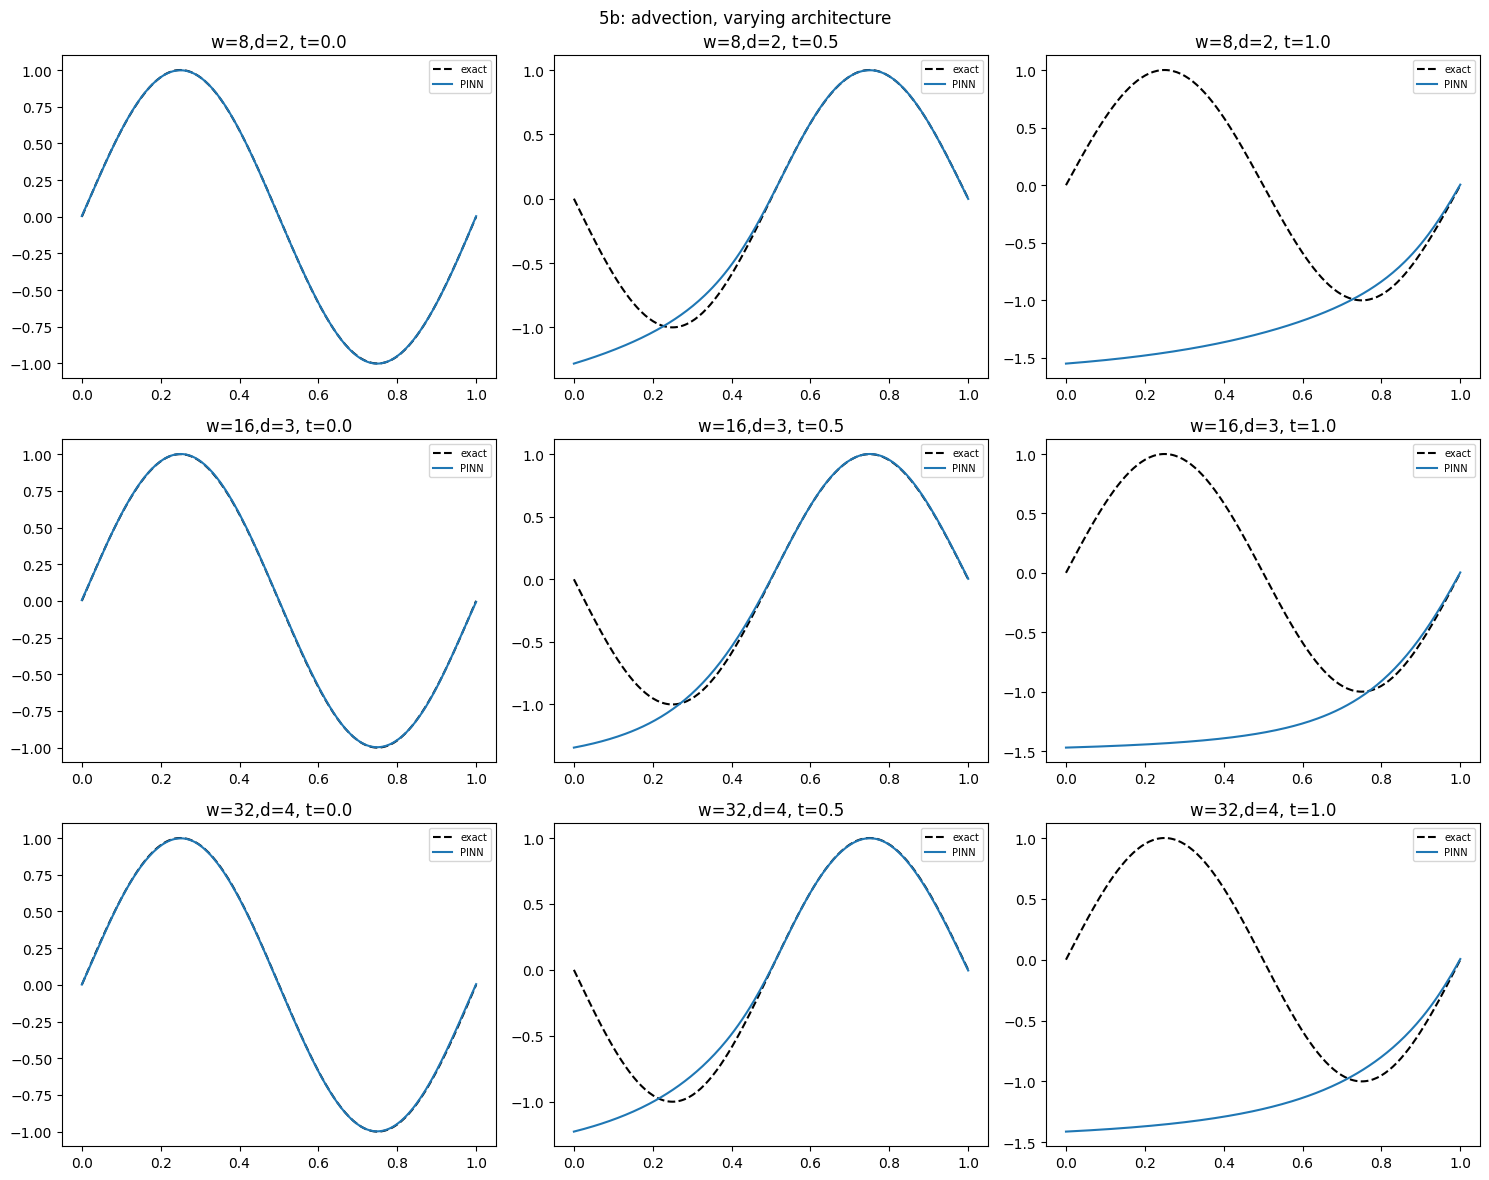

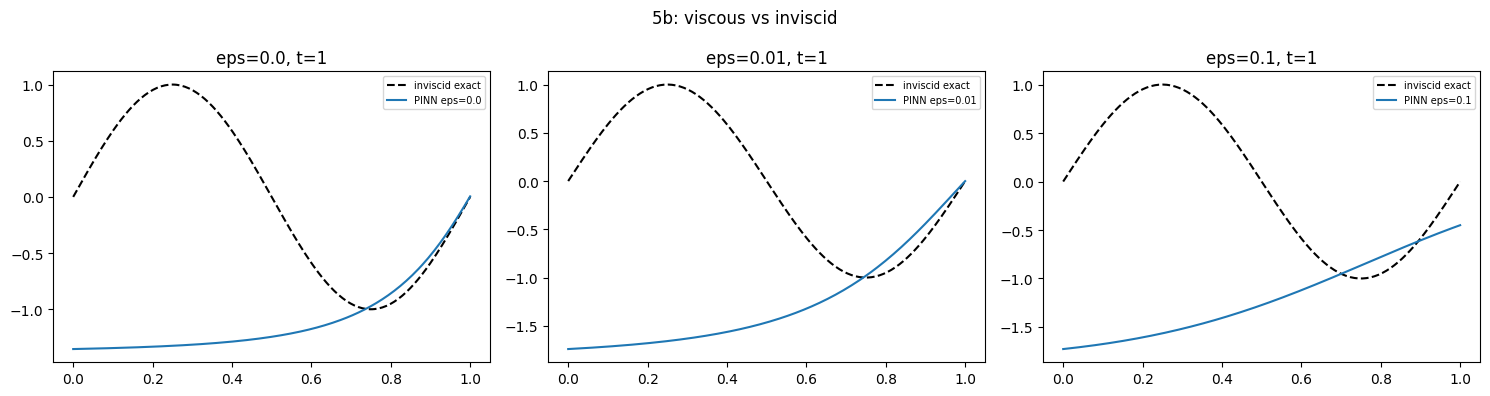

In [9]:
# ============================================================
# 5b: advection u_t + c*u_x = 0, vary architecture and add viscous term
# IC: u(x,0) = sin(2*pi*x), exact: u = sin(2*pi*(x - c*t))
# ============================================================

c = 1.0
T_adv = 1.0
def exact_5b(x, t):
    return torch.sin(2 * torch.pi * (x - c * t))

def pinn_loss_5b(model, xt_int, xt_ic, eps=0.0):
    xt_int.requires_grad_(True)
    u = model(xt_int)
    du = grad(u, xt_int)
    u_t = du[:, 1:2]
    u_x = du[:, 0:1]
    if eps > 0:
        u_xx = grad(u_x, xt_int)[:, 0:1]
        pde = (u_t + c * u_x - eps * u_xx).pow(2).mean()
    else:
        pde = (u_t + c * u_x).pow(2).mean()
    u_ic = model(xt_ic)
    u0   = exact_5b(xt_ic[:, 0:1], torch.zeros_like(xt_ic[:, 1:2]))
    ic   = (u_ic - u0).pow(2).mean()
    return pde + ic

configs = [(8, 2), (16, 3), (32, 4)]
x_plot = torch.linspace(0, 1, 200).unsqueeze(1)

fig, axes = plt.subplots(len(configs), 3, figsize=(15, 4*len(configs)))
t_vals = [0.0, 0.5, 1.0]
for row, (w, d) in enumerate(configs):
    xt_int = torch.stack([torch.rand(500), torch.rand(500) * T_adv], dim=1)
    xt_ic  = torch.stack([torch.rand(500), torch.zeros(500)], dim=1)
    model = MLP(w, d, in_dim=2)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    for _ in range(8000):
        opt.zero_grad()
        loss = pinn_loss_5b(model, xt_int, xt_ic)
        loss.backward()
        opt.step()
    for col, t_val in enumerate(t_vals):
        t_plot = torch.full_like(x_plot, t_val)
        xt = torch.cat([x_plot, t_plot], dim=1)
        with torch.no_grad():
            u_pred = model(xt)
        u_true = exact_5b(x_plot, t_plot)
        axes[row, col].plot(x_plot.numpy(), u_true.numpy(), 'k--', label='exact')
        axes[row, col].plot(x_plot.numpy(), u_pred.numpy(), label='PINN')
        axes[row, col].set_title(f'w={w},d={d}, t={t_val}')
        axes[row, col].legend(fontsize=7)
plt.suptitle('5b: advection, varying architecture'); plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, eps in zip(axes, [0.0, 0.01, 0.1]):
    xt_int = torch.stack([torch.rand(500), torch.rand(500) * T_adv], dim=1)
    xt_ic  = torch.stack([torch.rand(500), torch.zeros(500)], dim=1)
    model = MLP(16, 3, in_dim=2)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    for _ in range(8000):
        opt.zero_grad()
        loss = pinn_loss_5b(model, xt_int, xt_ic, eps=eps)
        loss.backward()
        opt.step()
    t_plot = torch.full_like(x_plot, 1.0)
    xt = torch.cat([x_plot, t_plot], dim=1)
    with torch.no_grad():
        u_pred = model(xt)
    u_true = exact_5b(x_plot, t_plot)
    ax.plot(x_plot.numpy(), u_true.numpy(), 'k--', label='inviscid exact')
    ax.plot(x_plot.numpy(), u_pred.numpy(), label=f'PINN eps={eps}')
    ax.set_title(f'eps={eps}, t=1'); ax.legend(fontsize=7)
plt.suptitle('5b: viscous vs inviscid'); plt.tight_layout(); plt.show()

### 5.5c: time-blocked wave equation

block 0: t in [0.00, 0.25]
block 1: t in [0.25, 0.50]
block 2: t in [0.50, 0.75]
block 3: t in [0.75, 1.00]


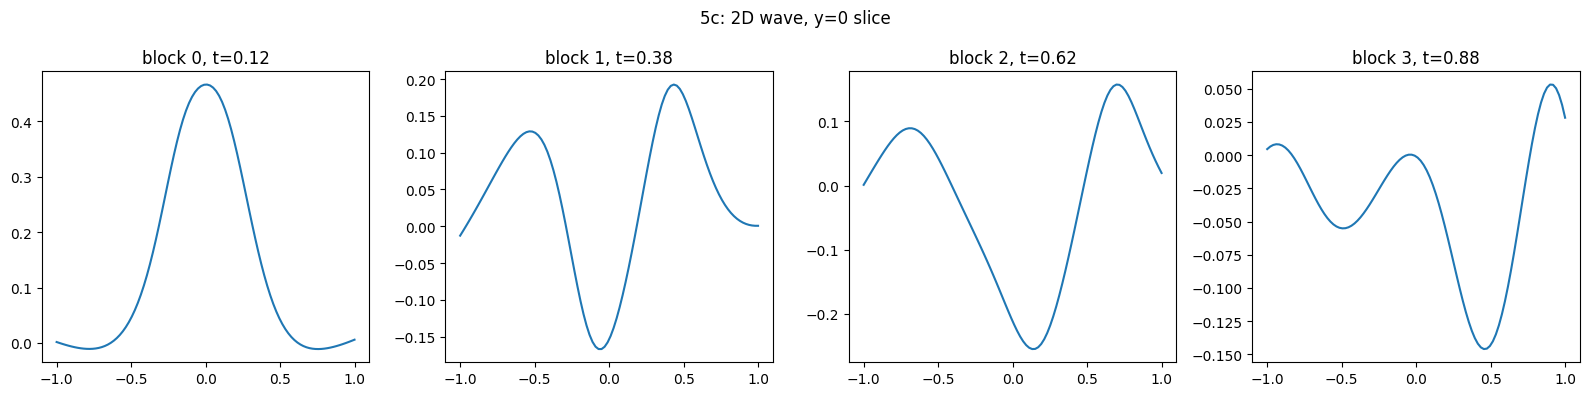

In [10]:
# ============================================================
# 5c: 2D wave with time-blocking
# u_tt - u_xx - u_yy = 0 on (-1,1)^2 x (0,T)
# IC: u = exp(-gamma*(x^2+y^2)), u_t = 0
# BC: u = 0 on boundary
# ============================================================

gamma = 20.0
T_wave = 1.0
n_blocks = 4
T_block = T_wave / n_blocks

def pinn_loss_wave(model, xyt_int, xyt_ic, u_ic, ut_ic, xyt_bc):
    xyt_int.requires_grad_(True)
    u = model(xyt_int)
    du = grad(u, xyt_int)
    u_t = du[:, 2:3]; u_x = du[:, 0:1]; u_y = du[:, 1:2]
    u_tt = grad(u_t, xyt_int)[:, 2:3]
    u_xx = grad(u_x, xyt_int)[:, 0:1]
    u_yy = grad(u_y, xyt_int)[:, 1:2]
    pde = (u_tt - u_xx - u_yy).pow(2).mean()

    xyt_ic.requires_grad_(True)
    u_pred_ic = model(xyt_ic)
    ic_pos = (u_pred_ic - u_ic).pow(2).mean()
    du_ic = grad(u_pred_ic, xyt_ic)[:, 2:3]
    ic_vel = (du_ic - ut_ic).pow(2).mean()

    bc = model(xyt_bc).pow(2).mean()
    return pde + ic_pos + ic_vel + bc

def sample_wave_block(t_start, t_end, n_int=1000, n_bc=200):
    x_int = torch.rand(n_int) * 2 - 1
    y_int = torch.rand(n_int) * 2 - 1
    t_int = torch.rand(n_int) * (t_end - t_start) + t_start
    xyt_int = torch.stack([x_int, y_int, t_int], dim=1)

    x_ic = torch.rand(n_int) * 2 - 1
    y_ic = torch.rand(n_int) * 2 - 1
    t_ic = torch.full((n_int,), t_start)
    xyt_ic = torch.stack([x_ic, y_ic, t_ic], dim=1)

    n_face = n_bc // 4
    faces = []
    for fixed, idx in [(-1,0),(1,0),(-1,1),(1,1)]:
        r = torch.rand(n_face) * 2 - 1
        t = torch.rand(n_face) * (t_end - t_start) + t_start
        if idx == 0:
            faces.append(torch.stack([torch.full((n_face,), fixed), r, t], dim=1))
        else:
            faces.append(torch.stack([r, torch.full((n_face,), fixed), t], dim=1))
    xyt_bc = torch.cat(faces, dim=0)
    return xyt_int, xyt_ic, xyt_bc

def u0(x, y):
    return torch.exp(-gamma * (x**2 + y**2))

prev_model = None
models = []
for block in range(n_blocks):
    t_start = block * T_block
    t_end   = (block + 1) * T_block
    print(f'block {block}: t in [{t_start:.2f}, {t_end:.2f}]')
    xyt_int, xyt_ic, xyt_bc = sample_wave_block(t_start, t_end)

    if block == 0:
        u_ic_vals  = u0(xyt_ic[:, 0:1], xyt_ic[:, 1:2])
        ut_ic_vals = torch.zeros_like(u_ic_vals)
    else:
        xyt_eval = xyt_ic.clone().requires_grad_(True)
        u_prev = prev_model(xyt_eval)
        ut_ic_vals = torch.autograd.grad(u_prev, xyt_eval,
            grad_outputs=torch.ones_like(u_prev))[0][:, 2:3].detach()
        u_ic_vals = u_prev.detach()

    model = MLP(16, 4, in_dim=3)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    for _ in range(5000):
        opt.zero_grad()
        loss = pinn_loss_wave(model, xyt_int, xyt_ic, u_ic_vals, ut_ic_vals, xyt_bc)
        loss.backward()
        opt.step()
    models.append(model)
    prev_model = model

fig, axes = plt.subplots(1, n_blocks, figsize=(16, 4))
x_plot = torch.linspace(-1, 1, 100)
for i, (ax, m) in enumerate(zip(axes, models)):
    t_mid = (i + 0.5) * T_block
    xyt = torch.stack([x_plot, torch.zeros(100), torch.full((100,), t_mid)], dim=1)
    with torch.no_grad():
        u_pred = m(xyt)
    ax.plot(x_plot.numpy(), u_pred.numpy())
    ax.set_title(f'block {i}, t={t_mid:.2f}')
plt.suptitle('5c: 2D wave, y=0 slice'); plt.tight_layout(); plt.show()